# Applying the Trained Models

This notebook applies trained PINN-MSCNN models to the MODEST Hinode/SP dataset and performs comprehensive analysis including:
- Model loading and inference with uncertainty quantification (Monte Carlo Dropout)
- Spatial maps comparison (predictions vs ground truth)
- Statistical analysis (correlation, RMSE, bias)
- Vertical atmospheric profile comparison
- Multi-model comparison (no physics, WFA only, all physics)
- Error analysis across optical depths

## 0. Prerequisites

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import torch
import astropy.units as u
from pathlib import Path
import sys
from scipy.stats import pearsonr
import pandas as pd
from typing import Dict, Tuple, Optional

# Add parent directories to path
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN")
from utils.modest_data import ModestData
from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.normalizer import MhdNormalizer, StokesNormalizer
from utils.analysis_functions import (
    plot_prediction_comparison,
    compare_models_at_optical_depth,
    plot_mean_vs_optical_depth,
    analyze_error_by_magnitude,
    plot_uncertainty_vs_error,
    plot_jointplot_comparison,
    plot_combined_jointplot
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Base images save path
images_base_path = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images")
images_save_path = images_base_path / "modest_analysis/whole_region"

print("✓ All imports successful")

✓ All imports successful


## 1. Load MODEST Data

In [10]:
data_path = Path("/scratchsan/observatorio/juagudeloo/data")

In [11]:
modest = ModestData()
modest.load_all(apply_mask=False)
print("✓ MODEST data loaded successfully")
print(f"  Continuum shape: {modest.continuum.shape}")
print(f"  Stokes I shape: {modest.obs_stokes['I'].shape}")
print(f"  Wavelength points: {len(modest.wl)}")

✓ MODEST data loaded successfully
  Continuum shape: (390, 858)
  Stokes I shape: (390, 858, 112)
  Wavelength points: 112


In [12]:
# Load normalizers
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

# Normalize Stokes data
normalized_stokes = stokes_normalizer.transform(modest.obs_stokes)
print("✓ Normalizers loaded and Stokes data normalized")

Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21
Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json
✓ Normalizers loaded and Stokes data normalized


## 2. Visualize FOV and Disk Center

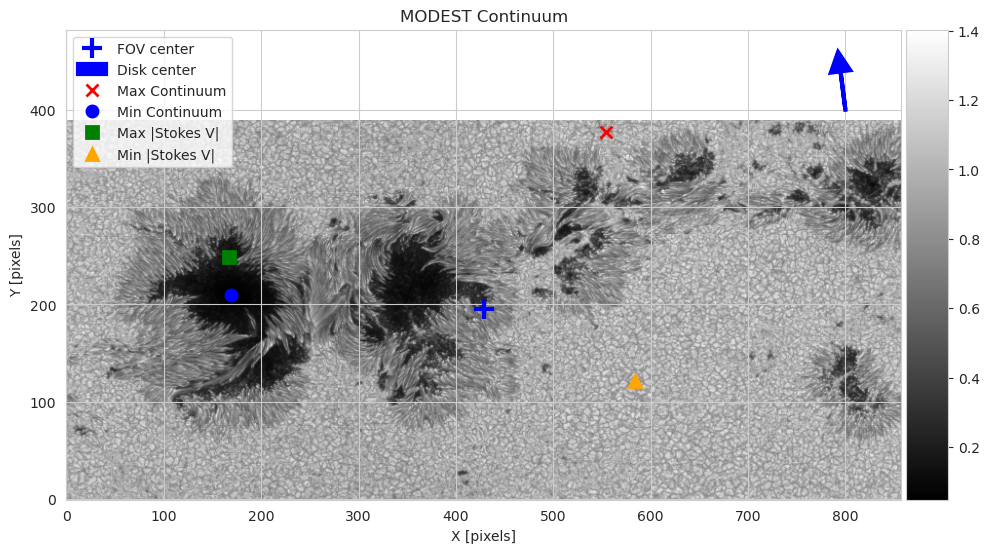

In [13]:
y_center_fov_arcsec = -126.0
x_center_fov_arcsec = 16.0
pixel_scale = 0.32
x_center_fov_pixel = modest.continuum.shape[1] / 2
y_center_fov_pixel = modest.continuum.shape[0] / 2
x_disk_offset_arcsec = 0 - x_center_fov_arcsec
y_disk_offset_arcsec = 0 - y_center_fov_arcsec
x_disk_offset_pixels = x_disk_offset_arcsec / pixel_scale
y_disk_offset_pixels = y_disk_offset_arcsec / pixel_scale
x_disk_center = x_center_fov_pixel + x_disk_offset_pixels
y_disk_center = y_center_fov_pixel + y_disk_offset_pixels
arrow_start_x = 800
arrow_start_y = 400
arrow_dx = x_disk_offset_pixels/10
arrow_dy = y_disk_offset_pixels/10

modest.plot_continuum(
    x_center_fov_pixel=x_center_fov_pixel,
    y_center_fov_pixel=y_center_fov_pixel,
    disk_center=(x_disk_center, y_disk_center),
    arrow_params=(arrow_start_x, arrow_start_y, arrow_dx, arrow_dy)
)

## 3. Load and Compare Multiple Models

We'll load three models trained with different physics regularization:
1. **No Physics**: Pure supervised learning
2. **WFA Only**: Weak-Field Approximation for B_LOS
3. **All Physics**: WFA + Gradient Smoothness

In [14]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model configurations to compare
model_configs = {
    'no_physics_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics 60 to 100',
        'color': 'blue'
    },
    'wfa_only_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only 60 to 100',
        'color': 'orange'
    },
    'all_physics_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/all_physics_terms/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.02,
        'label': 'All Physics 60 to 100',
        'color': 'green'
    },
    "no_physics_100_to_200": {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_100_to_200/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics 100 to 200',
        'color': 'blue'
    },
    'wfa_only_100_to_200': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_100_to_200/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only 100 to 200',
        'color': 'orange'
    },
}

def load_model(config: Dict) -> PhysicsInformedMSCNN:
    """Load a trained PINN-MSCNN model."""
    model = PhysicsInformedMSCNN(
        scales=[1, 2, 3],
        in_channels=2,
        c1_filters=16,
        c2_filters=32,
        kernel_size=5,
        pool_size=2,
        n_linear_layers=4,
        output_features=3*21,
        input_length=112,
        dropout_rate=0.2,
        use_physics=config['use_physics'],
        lambda_wfa=config['lambda_wfa'],
        lambda_doppler=config['lambda_doppler'],
        lambda_temp=config['lambda_temp'],
        lambda_physics=config['lambda_physics'],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(config['path'], map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

# Load all models
models = {}
for name, config in model_configs.items():
    print(f"Loading {config['label']}...")
    models[name] = load_model(config)
    print(f"  ✓ Model loaded successfully")
    if 'test_metrics' in torch.load(config['path'], map_location='cpu'):
        metrics = torch.load(config['path'], map_location='cpu')['test_metrics']
        print(f"  Training metrics: B_LOS RRMSE={metrics.get('blos_rrmse_tau_avg', 'N/A'):.4f}, "
              f"V_LOS RRMSE={metrics.get('vlos_rrmse_tau_avg', 'N/A'):.4f}")

print(f"\n✓ All {len(models)} models loaded")

Using device: cuda
Loading No Physics 60 to 100...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3127
Loading WFA Only 60 to 100...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3170
Loading All Physics 60 to 100...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3163
Loading No Physics 100 to 200...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=4.3830, V_LOS RRMSE=1.3212
Loading WFA Only 100 to 200...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=14.4114, V_LOS RRMSE=1.3200

✓ All 5 models loaded


## 4. Prepare Input Data

In [15]:
# Prepare input tensor
I_t = normalized_stokes["I"]
V_t = normalized_stokes["V"]
inputs = np.stack([I_t, V_t], axis=2)  # Shape: (H, W, 2, nλ)
H, W, Nstokes, Nlambda = inputs.shape

# Convert to torch tensor
inputs_tensor = torch.tensor(inputs, dtype=torch.float32).permute(0, 1, 3, 2)  # (H, W, nλ, 2)
inputs_tensor = inputs_tensor.reshape(H*W, Nstokes, Nlambda).to(device)  # (H*W, 2, nλ)

print(f"Input tensor shape: {inputs_tensor.shape}")
print(f"Total pixels: {H*W:,}")

Input tensor shape: torch.Size([334620, 2, 112])
Total pixels: 334,620


## 5. Run Inference with Uncertainty Quantification

Using Monte Carlo Dropout (30 stochastic forward passes) to estimate prediction uncertainty.

In [16]:
# Run inference for all models
all_predictions = {}
logtau = np.arange(-2, 0.1, 0.1)

print("\n" + "="*70)
for model_name, model in models.items():
    print(f"\nRunning inference for {model_configs[model_name]['label']}...")
    
    # Option 1: Use the model's built-in method directly
    mean_atm, std_atm = model.run_inference_with_uncertainty(
        inputs=inputs_tensor,
        mhd_normalizer=mhd_normalizer,
        batch_size=512,
        stochastic_steps=30,
        H=H,
        W=W,
        n_heights=21,
        verbose=True
    )
    
    # Option 2: Use the wrapper function from analysis_functions (backward compatible)
    # mean_atm, std_atm = run_inference_with_uncertainty(
    #     model, inputs_tensor, mhd_normalizer,
    #     batch_size=512, stochastic_steps=30,
    #     H=H, W=W, n_heights=21
    # )
    
    all_predictions[model_name] = {
        'mean': mean_atm,
        'std': std_atm,
        'label': model_configs[model_name]['label'],
        'color': model_configs[model_name]['color']
    }
    print(f"  T range: {mean_atm['T'].min():.1f} - {mean_atm['T'].max():.1f} K")
    print(f"  Vz range: {mean_atm['Vz'].min():.2f} - {mean_atm['Vz'].max():.2f} km/s")
    print(f"  Bz range: {mean_atm['Bz'].min():.2f} - {mean_atm['Bz'].max():.2f} G")

print("\n" + "="*70)
print("✓ All model inferences complete")



Running inference for No Physics 60 to 100...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)


  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])
  ✓ Inference complete
    T: mean range [-29515.16, 13117.91], avg std = 340.00
    Vz: mean range [-79.34, 50.81], avg std = 1.61
    Bz: mean range [-17213399376627349422342144.00, inf], avg std = nan
  T range: -29515.2 - 13117.9 K
  Vz range: -79.34 - 50.81 km/s
  Bz range: -17213399376627349422342144.00 - inf G

Running inference for WFA Only 60 to 100...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/33

## 6. Analysis Functions

Analysis functions have been moved to `utils/analysis_functions.py` for reusability.

## 7. Single Model Analysis

Analyze each model individually at a specific optical depth.

In [17]:
modest_logtau = list(modest.spinor_atm["T"].keys())

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✗ Failed to plot comparison for No Physics 60 to 100 at log(tau)=-2.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 60 to 100 at log(tau)=-2.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:100: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


✗ Failed to plot comparison for All Physics 60 to 100 at log(tau)=-2.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 100 to 200 at log(tau)=-2.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 100 to 200 at log(tau)=-2.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 60 to 100 at log(tau)=-2.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 60 to 100 at log(tau)=-2.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for All Physics 60 to 100 at log(tau)=-2.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 100 to 200 at log(tau)=-2.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 100 to 200 at log(tau)=-2.0 for Vz: unsupported operand

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


✗ Failed to plot comparison for WFA Only 100 to 200 at log(tau)=-0.8 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 60 to 100 at log(tau)=-0.8 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 60 to 100 at log(tau)=-0.8 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for All Physics 60 to 100 at log(tau)=-0.8 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 100 to 200 at log(tau)=-0.8 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 100 to 200 at log(tau)=-0.8 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 60 to 100 at log(tau)=-0.8 for T: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 60 to 100 at log(tau)=-0.8 for T: unsupported operand type(

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


✗ Failed to plot comparison for WFA Only 60 to 100 at log(tau)=0.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for All Physics 60 to 100 at log(tau)=0.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 100 to 200 at log(tau)=0.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 100 to 200 at log(tau)=0.0 for Bz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 60 to 100 at log(tau)=0.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for WFA Only 60 to 100 at log(tau)=0.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for All Physics 60 to 100 at log(tau)=0.0 for Vz: unsupported operand type(s) for /: 'str' and 'str'
✗ Failed to plot comparison for No Physics 100 to 200 at log(tau)=0.0 for Vz: unsupported operand type(s) 

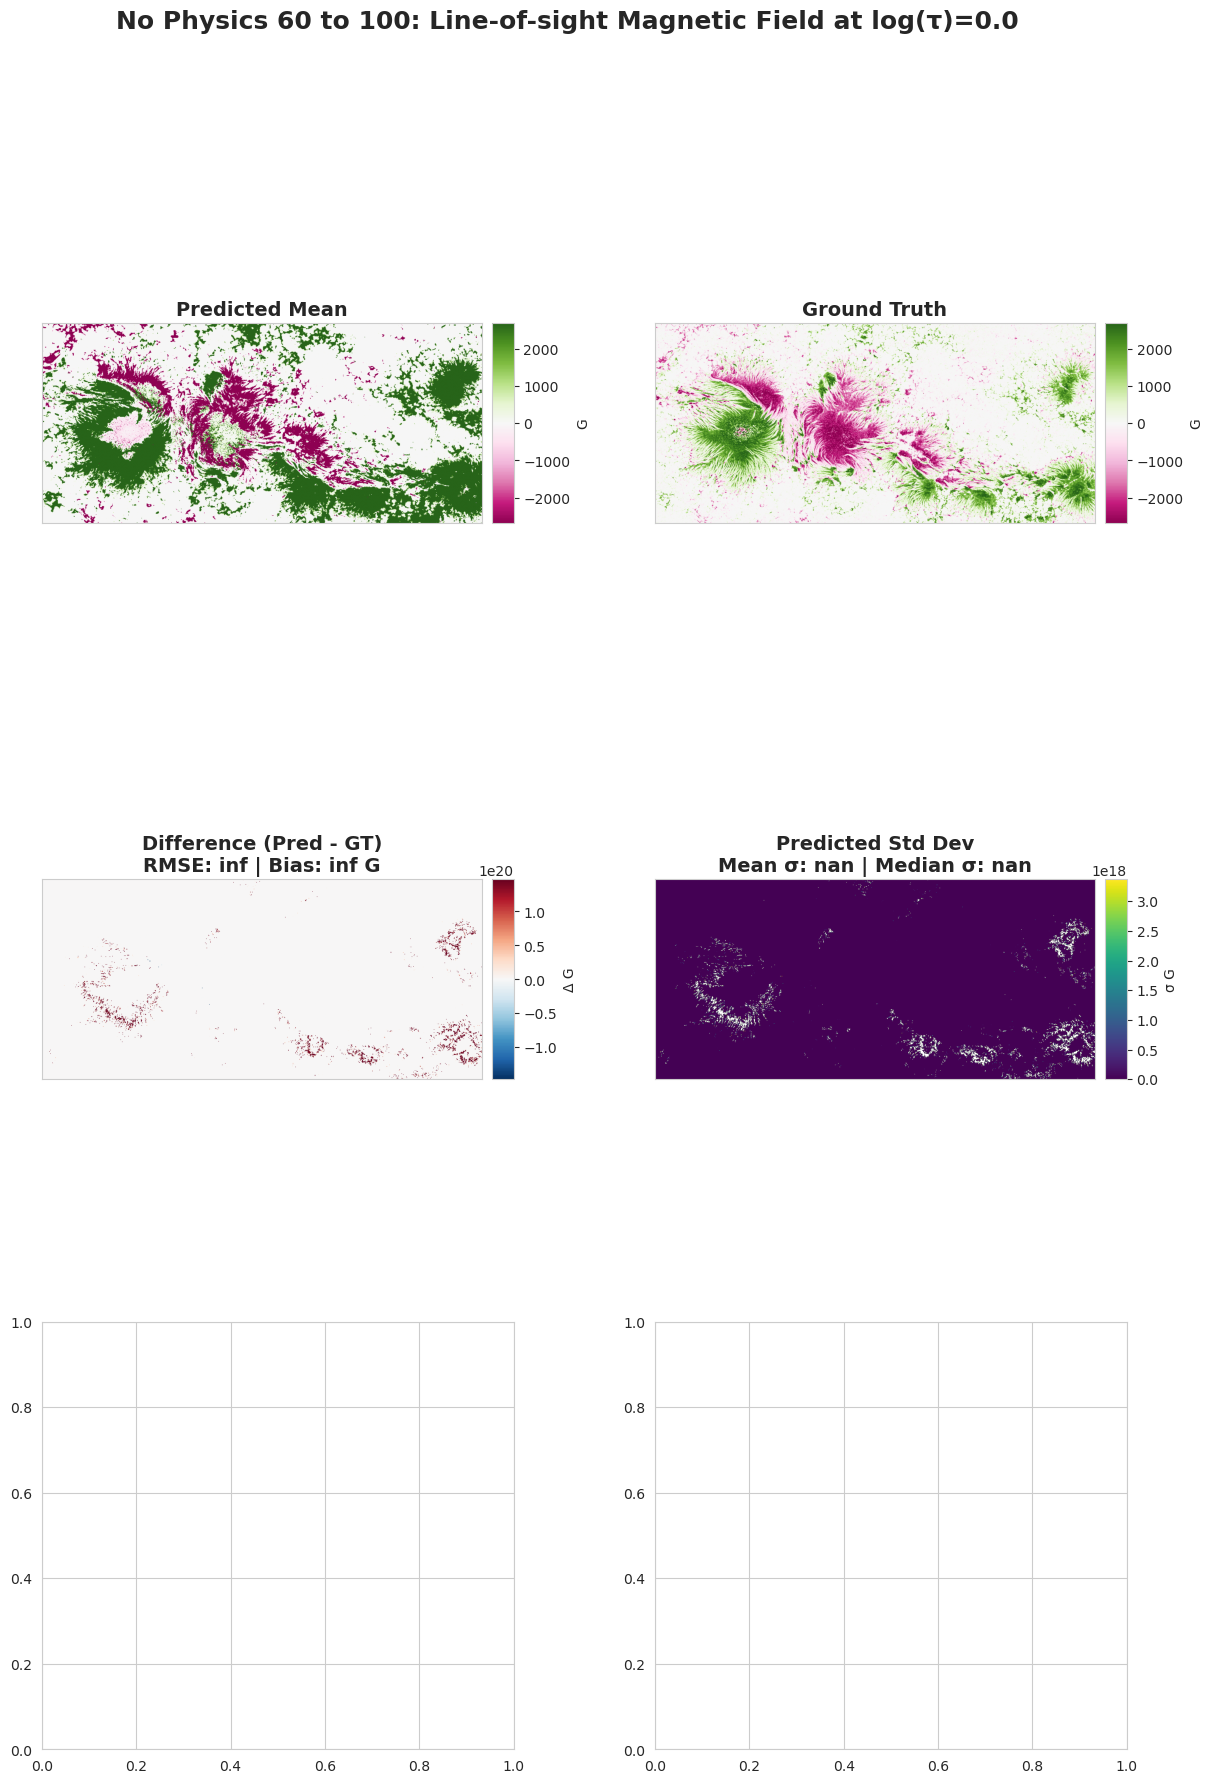

In [18]:
# Choose optical depth and parameter
logtau = np.arange(-2, 0.1, 0.1)

# Plot each model
for od_to_plot in modest_logtau:
    for mag_to_plot in ["Bz", "Vz", "T"]:
        for model_name, pred_data in all_predictions.items():
            try:
                filename = f"{pred_data['label'].lower().replace(' ', '_')}_comparison_{mag_to_plot}_logtau_{od_to_plot}.png"
                plot_prediction_comparison(
                    mean_atm=pred_data['mean'],
                    std_atm=pred_data['std'],
                    ground_truth=modest.spinor_atm,
                    mag_to_plot=mag_to_plot,
                    od_to_plot=od_to_plot,
                    logtau=logtau,
                    model_label=pred_data['label'],
                    figsize=(14, 20),
                    save_dir=images_save_path,
                    filename=filename
                )
                print(f"✓ Saved comparison plot for {pred_data['label']} at log(tau)={od_to_plot} for {mag_to_plot}")
            except Exception as e:
                print(f"✗ Failed to plot comparison for {pred_data['label']} at log(tau)={od_to_plot} for {mag_to_plot}: {e}")

## 8. Multi-Model Comparison

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_T_logtau_-2.0.json
✓ Saved model comparison plot for T at log(tau)=-2.0
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Vz_logtau_-2.0.json
✓ Saved model comparison plot for Vz at log(tau)=-2.0


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:314: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Bz_logtau_-2.0.json
✓ Saved model comparison plot for Bz at log(tau)=-2.0
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_T_logtau_-0.8.json
✓ Saved model comparison plot for T at log(tau)=-0.8
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Vz_logtau_-0.8.json
✓ Saved model comparison plot for Vz at log(tau)=-0.8
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comparison/model_comparison_Bz_logtau_-0.8.json
✓ Saved model comparison plot for Bz at log(tau)=-0.8
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/model_comp

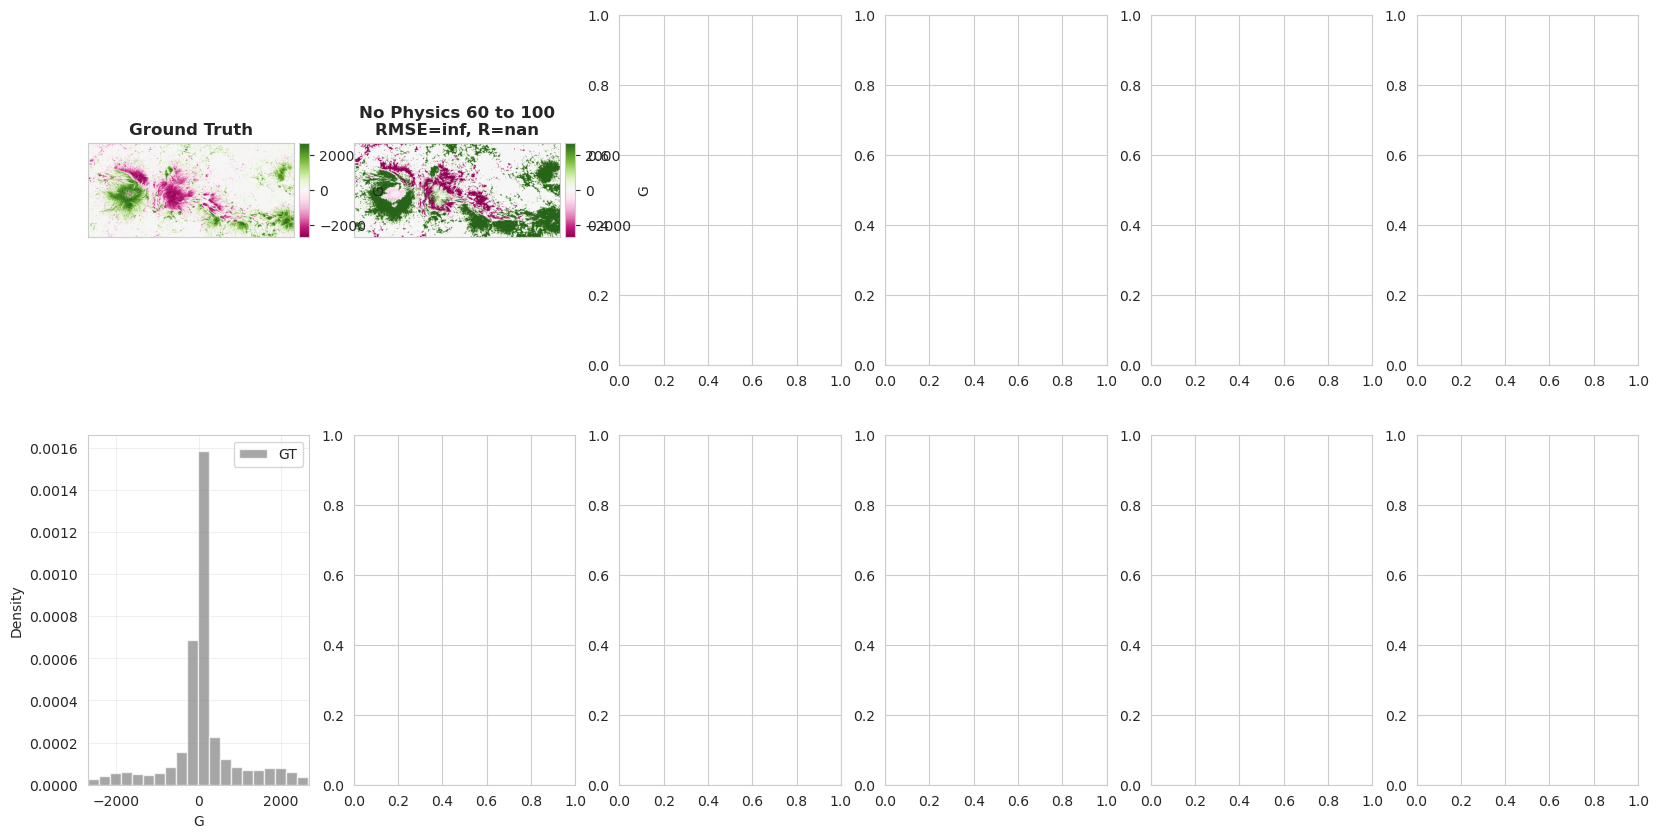

In [19]:
# Compare all models side-by-side
for od_to_plot in modest_logtau:
    for param in ['T', 'Vz', 'Bz']:
        filename = f"model_comparison_{param}_logtau_{od_to_plot}.png"
        try:
            compare_models_at_optical_depth(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=param,
                od_to_plot=od_to_plot,
                logtau=logtau,
                figsize=(20, 10),
                save_dir=images_save_path,
                filename=filename
            )
            print(f"✓ Saved model comparison plot for {param} at log(tau)={od_to_plot}")
        except Exception as e:
            print(f"Error comparing models for {param} at log(tau)={od_to_plot}: {e}")

## 9. Metrics Across Optical Depths

In [20]:
# Example 3: Compare all models with ground truth
for model_name, pred_data in all_predictions.items():
    filename = f"{pred_data['label'].lower().replace(' ', '_')}_mean_vs_optical_depth.png"
    print(f"\n{'='*80}")
    print(f"Model: {pred_data['label']}")
    print(f"{'='*80}")

    plot_mean_vs_optical_depth(
        mean_atm=pred_data['mean'],
        std_atm=pred_data['std'],
        logtau=logtau,
        figsize=(18, 6),
        log_scale={'T': False, 'Vz': False, 'Bz': False},
        ylims={'T': (2000, 7000), 'Vz': (-11, 7), 'Bz': (-2000, 2000)},
        ground_truth=modest.spinor_atm,
        save_dir=images_save_path,
        filename=filename
    )
    print(f"✓ Saved mean vs optical depth plot for {pred_data['label']}")


Model: No Physics 60 to 100
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/mean_vs_optical_depth/no_physics_60_to_100_mean_vs_optical_depth.json

Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       3626.12 ±   584.55 K
    Difference:       2810.62 (+344.7%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       4632.01 ±   235.59 K
    Difference:       -595.70 (-11.4%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       5896.79 ±   347.18 K
    Difference:       -210.81 (-3.5%)
    Status:        ✓ WITHIN ±1σ uncertainty

Line-of-sight Velocity (km/s):
----------------------------------------------------

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/whole_region/mean_vs_optical_depth/wfa_only_60_to_100_mean_vs_optical_depth.json

Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       3129.03 ±   336.31 K
    Difference:       2313.54 (+283.7%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       5098.76 ±   125.21 K
    Difference:       -128.95 (-2.5%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       6144.18 ±   219.99 K
    Difference:         36.59 (+0.6%)
    Status:        ✓ WITHIN ±1σ uncertainty

Line-of-sight Velocity (km/s):
----------------------------------------------------------------------
  log(τ) =  -

## 10. Seaborn-based Statistical Analysis

In [21]:
# 1. Separate jointplots for each model

for mag_to_plot in ["T", "Vz", "Bz"]:
    for od_to_plot in modest_logtau:
        try:
            print(f"\n{'='*80}")
            print(f"Separate Jointplots: {mag_to_plot}")
            print(f"{'='*80}")
            filename_prefix = f"jointplot_{mag_to_plot}_logtau_{od_to_plot}"
            plot_jointplot_comparison(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=mag_to_plot,
                od_val=od_to_plot,
                logtau=logtau,
                n_samples=10000,
                kind='reg',  # Options: 'scatter', 'hex', 'kde', 'reg',
                save_dir=images_save_path,
                filename_prefix=filename_prefix
            )
            print(f"✓ Saved jointplots for {mag_to_plot}")
        except Exception as e:
            print(f"Error plotting jointplots for {mag_to_plot}: {e}")


Separate Jointplots: T
Error plotting jointplots for T: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: T


Error plotting jointplots for T: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: T
Error plotting jointplots for T: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: Vz
Error plotting jointplots for Vz: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: Vz
Error plotting jointplots for Vz: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: Vz
Error plotting jointplots for Vz: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: Bz
Error plotting jointplots for Bz: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: Bz


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1014: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


Error plotting jointplots for Bz: unsupported operand type(s) for /: 'str' and 'str'

Separate Jointplots: Bz


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1014: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


Error plotting jointplots for Bz: unsupported operand type(s) for /: 'str' and 'str'



Combined Jointplot: T


Error plotting combined jointplot for T: unsupported operand type(s) for /: 'str' and 'str'

Combined Jointplot: T
Error plotting combined jointplot for T: unsupported operand type(s) for /: 'str' and 'str'

Combined Jointplot: T
Error plotting combined jointplot for T: unsupported operand type(s) for /: 'str' and 'str'

Combined Jointplot: Vz
Error plotting combined jointplot for Vz: unsupported operand type(s) for /: 'str' and 'str'

Combined Jointplot: Vz
Error plotting combined jointplot for Vz: unsupported operand type(s) for /: 'str' and 'str'

Combined Jointplot: Vz
Error plotting combined jointplot for Vz: unsupported operand type(s) for /: 'str' and 'str'

Combined Jointplot: Bz
Error plotting combined jointplot for Bz: Unable to allocate 427. TiB for an array with shape (58742485809134,) and data type float64

Combined Jointplot: Bz


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1187: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


Error plotting combined jointplot for Bz: Maximum allowed size exceeded

Combined Jointplot: Bz


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1187: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


Error plotting combined jointplot for Bz: Maximum allowed size exceeded


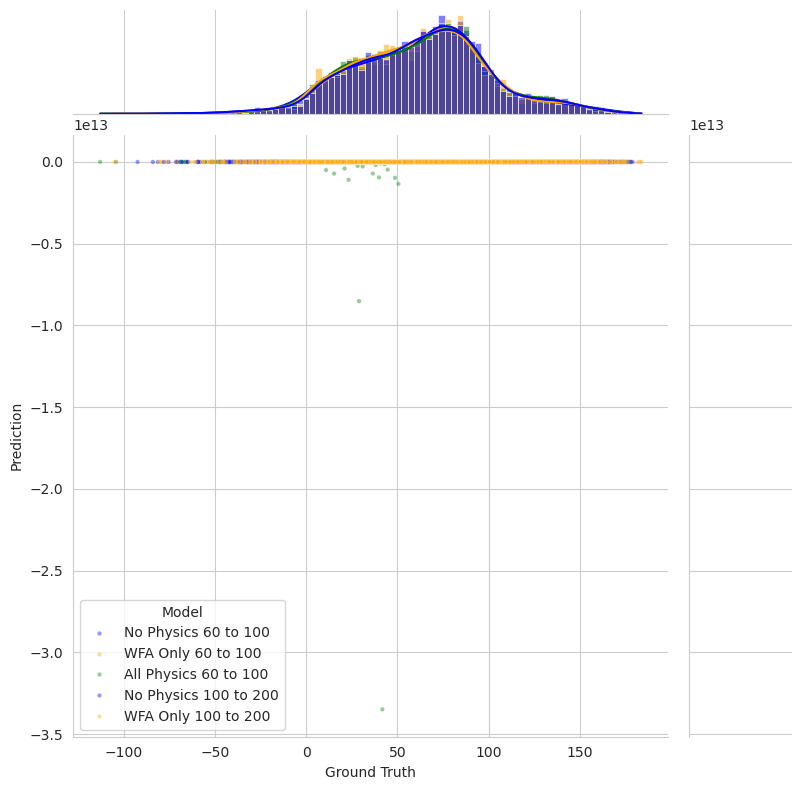

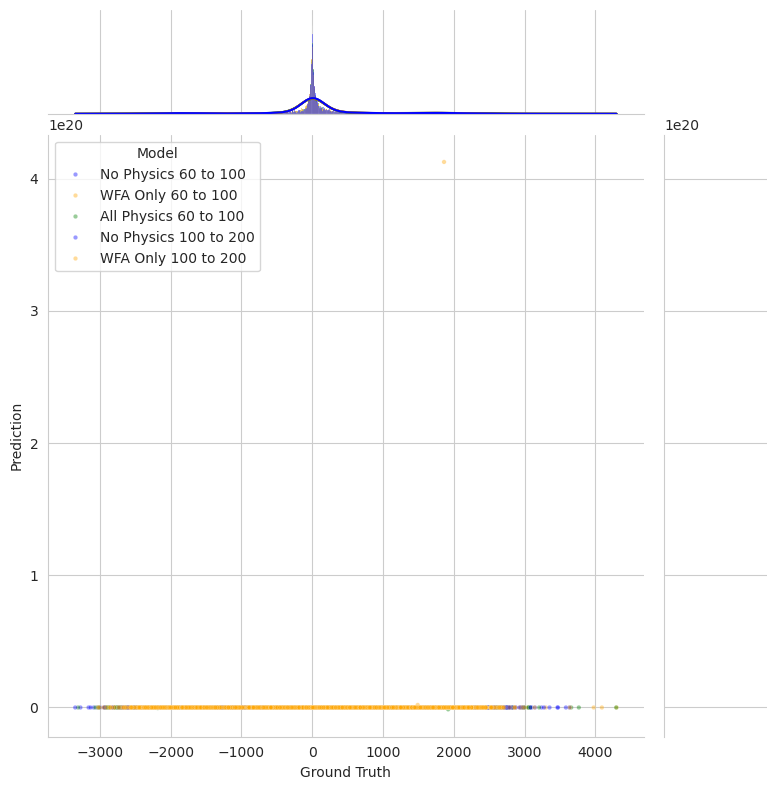

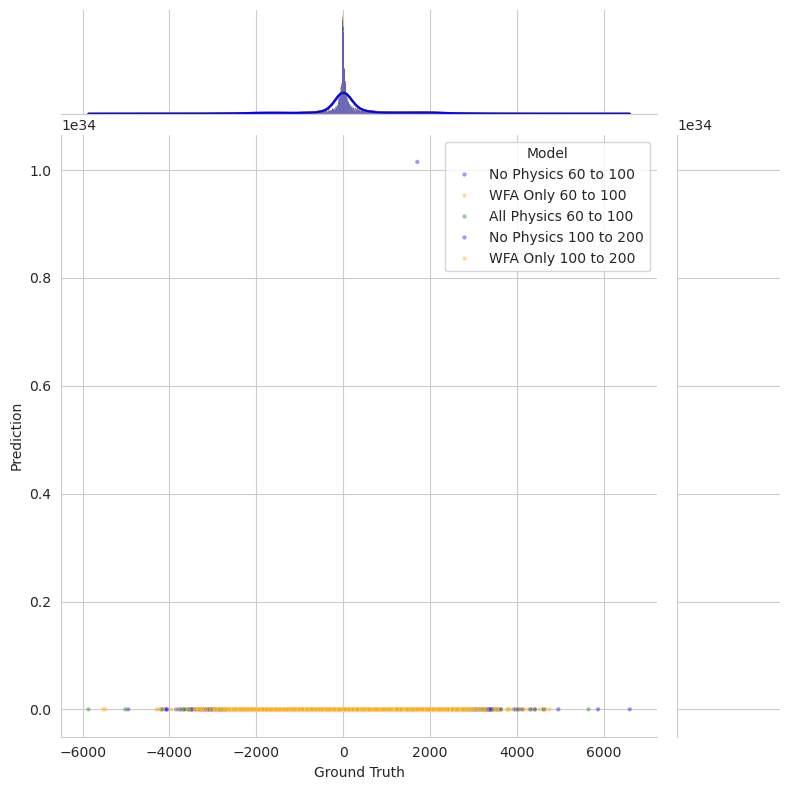

In [22]:
# 2. Combined jointplot with all models overlaid
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        print(f"\n{'='*80}")
        print(f"Combined Jointplot: {param}")
        print(f"{'='*80}")
        filename = f"combined_jointplot_{param}_logtau_{od_to_plot}.png"
        try:
            plot_combined_jointplot(
                all_predictions=all_predictions,
                ground_truth=modest.spinor_atm,
                mag_to_plot=param,
                od_val=od_to_plot,
                logtau=logtau,
                n_samples=5000,
                save_dir=images_save_path,
                filename=filename
            )
            print(f"✓ Saved combined jointplot for {param}")
        except Exception as e:
            print(f"Error plotting combined jointplot for {param}: {e}")

## 11. Error Analysis by Magnitude

IndexError: index 3 is out of bounds for axis 0 with size 3

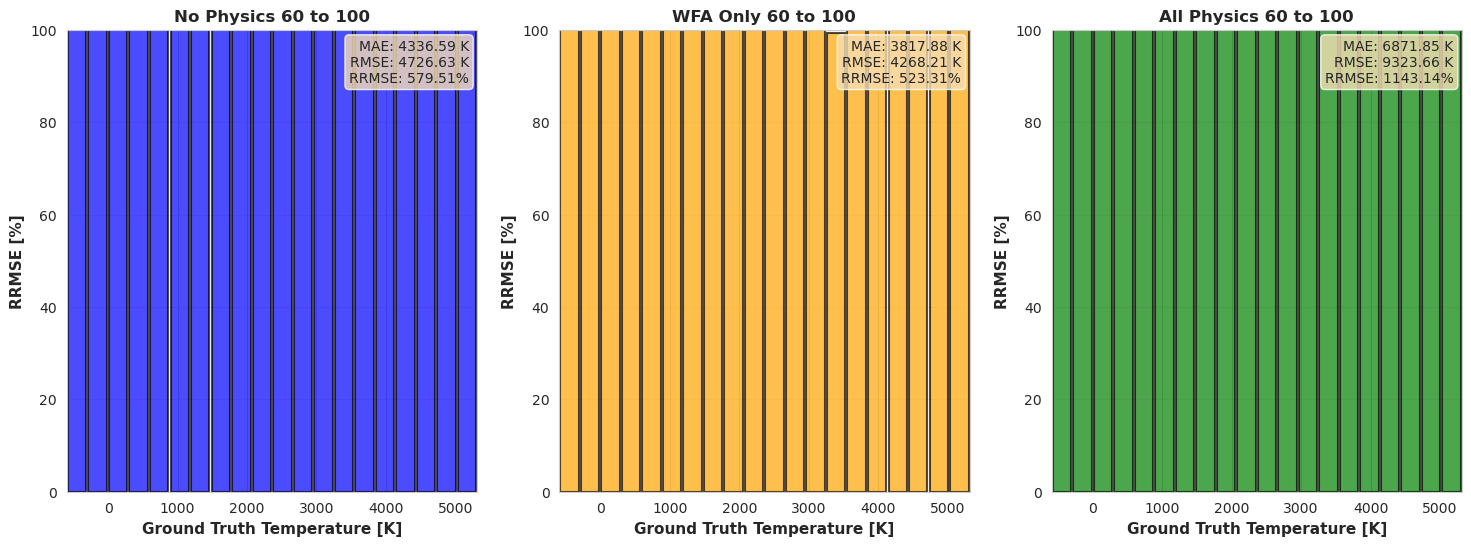

In [23]:
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"error_analysis_{param}_logtau_{od_to_plot}.png"
        analyze_error_by_magnitude(
            all_predictions=all_predictions,
            ground_truth=modest.spinor_atm,
            mag_to_analyze=param,  # Choose: "T", "Vz", or "Bz"
            od_val=od_to_plot,
            logtau=logtau,
            n_bins=20,
            plot_counts=False,
            use_absolute=False,
            rrmse_ylim=(0, 100),
            save_dir=images_save_path,
            filename=filename
        )
        print(f"✓ Saved error analysis plot for {param} at log(tau)={od_to_plot}")

## 12. Uncertainty Quantification Analysis

In [ ]:
# Run uncertainty analysis
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"uncertainty_vs_error_{param}_logtau_{od_to_plot}.png"
        plot_uncertainty_vs_error(
            all_predictions=all_predictions,
            ground_truth=modest.spinor_atm,
            mag_to_plot=param,
            od_val=od_to_plot,
            logtau=logtau,
            save_dir=images_save_path,
            filename=filename
        )
        print(f"✓ Saved uncertainty vs error plot for {param} at log(tau)={od_to_plot}")

✓ Saved uncertainty vs error plot for T at log(tau)=-2.0
✓ Saved uncertainty vs error plot for T at log(tau)=-0.8
✓ Saved uncertainty vs error plot for T at log(tau)=0.0
✓ Saved uncertainty vs error plot for Vz at log(tau)=-2.0
✓ Saved uncertainty vs error plot for Vz at log(tau)=-0.8
✓ Saved uncertainty vs error plot for Vz at log(tau)=0.0
✓ Saved uncertainty vs error plot for Bz at log(tau)=-2.0


/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


✓ Saved uncertainty vs error plot for Bz at log(tau)=-0.8
✓ Saved uncertainty vs error plot for Bz at log(tau)=0.0
